# Figure 3 Supplemental S6 — Extended analysis of image-change related activity

Split out from `figure_3_supplemental.ipynb`. Contains shared setup, the standalone image-change plots that feed the S6 composite, the shared SVM decoding cell (panel I), and the S6 composite assembly.

### Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import seaborn as sns
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

# Statistical analysis
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from scipy.stats import chi2

# Data access
from visual_behavior.data_access import loading as loading
import visual_behavior.data_access.utilities as utilities
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

# Utilities
import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf

# NOTE: %autoreload 2 was removed -- it reloads the entire visual_behavior +
# allensdk module tree before EVERY cell, which destabilizes and kills the
# kernel on these heavy-loading notebooks (dies at a random cell each run). To
# hot-reload just your plotting code while developing, without the crash, use:
#     %load_ext autoreload
#     %autoreload 1
#     %aimport visual_behavior.visualization.ophys.platform_paper_figures
%matplotlib inline

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/xarray/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain 

### Configuration

In [2]:
# When True, skip heavy-duty loading + slow-MLM heatmaps, exposure,
# active/passive, epoch, and image-selectivity analyses (fast iteration).
skip_slow_plots = False

save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_3_supplemental')
folder = 'population_activity'

# Create save directories if they don't exist
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

if not os.path.exists(os.path.join(save_dir, folder)):
    os.makedirs(os.path.join(save_dir, folder))

palette = utils.get_experience_level_colors()
experience_levels = utils.get_new_experience_levels()
experience_level_colors = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

### Data Loading

#### Metadata tables

In [3]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
behavior_sessions = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_behavior_sessions_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utils.get_cell_types()
experience_levels = utils.get_experience_levels()
palette = utils.get_experience_level_colors()


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

#### Load data tables

In [4]:
data_type = 'filtered_events'
session_subset = 'full_session'
inclusion_criteria = 'platform_experiment_table'

metrics_dir = loading.get_cell_metrics_dir()
filepath = os.path.join(metrics_dir, f'merged_model_free_metrics_table_{data_type}_{inclusion_criteria}.csv')
filtered_events_metrics_table = pd.read_csv(filepath, index_col=0)

metrics_table = filtered_events_metrics_table.copy()

# Merge with platform experiments
metrics_table = metrics_table.merge(platform_experiments.reset_index(),
                                   on=['ophys_experiment_id', 'experience_level'])


# # Create event-type specific dataframes
# image_mdf = metrics_table[(metrics_table.event_type == 'images')]
# change_mdf = metrics_table[(metrics_table.event_type == 'changes')]
# omission_mdf = metrics_table[(metrics_table.event_type == 'omissions')]

# # Create each_image specific dataframe
# each_image_mdf = metrics_table[(metrics_table.event_type == 'images') &
#                                (metrics_table.image_id.notna())].copy()

In [5]:
data_type = 'events'
interpolate = True
output_sampling_rate = 30
inclusion_criteria = 'platform_experiment_table'


In [6]:

# Image changes
event_type = 'all'
conditions = ['cell_specimen_id', 'is_change']
is_change_mdf = loading.get_multi_session_df_for_conditions(
    data_type, event_type, conditions, inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

change_mdf = is_change_mdf[is_change_mdf.is_change == True]
image_mdf = is_change_mdf[is_change_mdf.is_change == False]

# Omissions
conditions = ['cell_specimen_id', 'omitted']
omission_mdf = loading.get_multi_session_df_for_conditions(
    data_type, event_type, conditions, inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

omission_mdf = omission_mdf[omission_mdf.omitted == True]

# Per image
conditions = ['cell_specimen_id', 'is_change', 'image_name']
each_image_mdf = loading.get_multi_session_df_for_conditions(
    data_type, event_type, conditions, inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_platform_experiment_table.feather
there are 1881 experiments in the full multi_session_df
there are 400 experiments in the multi_session_df after limiting to platform experiments
there are 400 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_omitted_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_omitted_platform_experiment_table.feather
there are 1879 experiments in the full multi_session_df
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_image_name_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_image_name_platform_experiment_table.feather
there are 1885 experiments in the full multi_session_df
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


### Change response characterization

Population average responses and single-cell response heatmaps aligned to image
changes across experience levels, split by cohort (single-plane cohorts 1 & 2,
multi-plane cohort 3) and imaging depth. Population averages show the mean ± SEM
calcium event magnitude time-locked to image change onset. Heatmaps display
individual cell responses (rows) across experience levels (columns), sorted by
response strength, separately for matched and unmatched cells. These panels
correspond to PPT Figure S6 panels A-D.

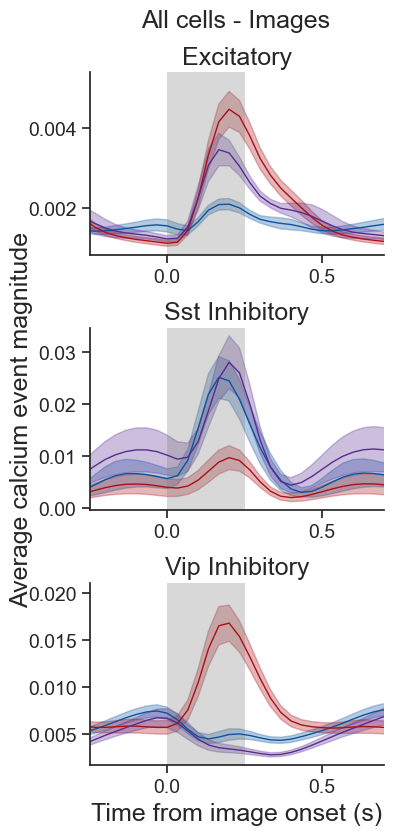

In [7]:
# Cell-matched population averages for images
xlim_seconds = [-0.25, 0.7]

suffix = '_images_all'
axes_column = 'cell_type'
hue_column = 'experience_level'

ax = ppf.plot_population_averages_for_conditions(
    image_mdf, data_type, 'all', axes_column, hue_column,
    horizontal=False, xlabel='Time from image onset (s)',
    ylabel='Average calcium event magnitude', legend=False,
    xlim_seconds=xlim_seconds, interval_sec=0.5,
    palette=palette, ax=None, title=None, suptitle='All cells - Images',
    save_dir=save_dir, folder='population_activity', suffix=suffix)

array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\ncells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\ncells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\ncells'>,
       <Axes: xlabel='Time from image onset (s)'>, <Axes: >], dtype=object)

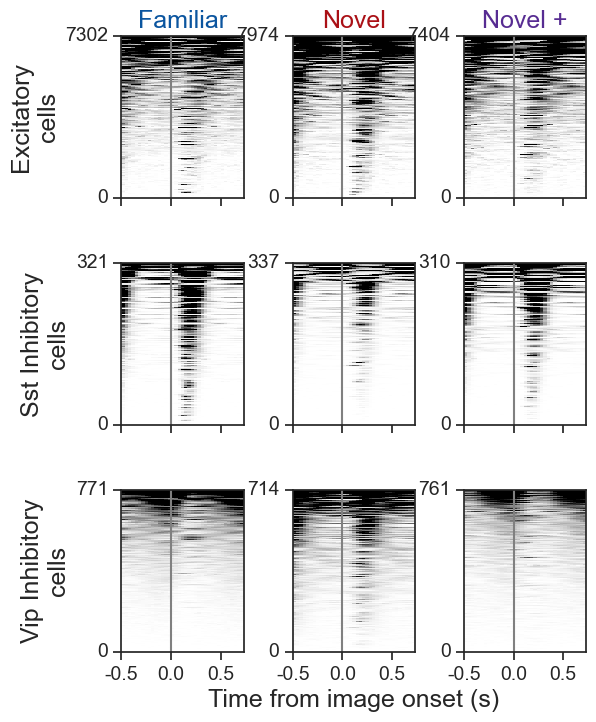

In [8]:

timestamps = image_mdf.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'

ppf.plot_response_heatmaps_for_conditions(
    image_mdf, timestamps, data_type, 'all', row_condition, col_condition, 
    col_to_sort_by='mean_baseline', suptitle='All cells - Images', exp_to_match='Familiar',
    xlabel='Time from image onset (s)', matched_cells_table=None,
    xlim_seconds=[-0.5, 0.75], match_cells=False, cbar=False, plot_epochs=False,
    save_dir=save_dir, folder='population_activity', suffix='_all_cells_images', ax=None)

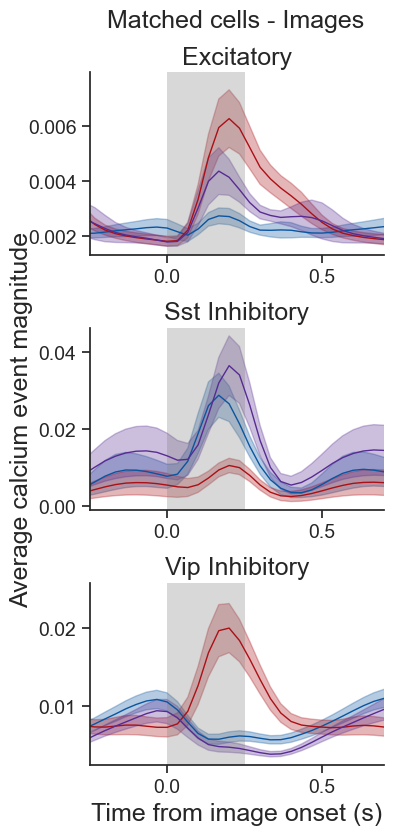

In [9]:
# Cell-matched population averages for images
matched = utilities.limit_to_cell_specimen_ids_matched_in_all_experience_levels(image_mdf)
xlim_seconds = [-0.25, 0.7]

suffix = '_images_matched'
axes_column = 'cell_type'
hue_column = 'experience_level'

ax = ppf.plot_population_averages_for_conditions(
    matched, data_type, 'all', axes_column, hue_column,
    horizontal=False, xlabel='Time from image onset (s)',
    ylabel='Average calcium event magnitude', legend=False,
    xlim_seconds=xlim_seconds, interval_sec=0.5,
    palette=palette, ax=None, title=None, suptitle='Matched cells - Images',
    save_dir=save_dir, folder='population_activity', suffix=suffix)

array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\nmatched cells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\nmatched cells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\nmatched cells'>,
       <Axes: xlabel='Time from image onset (s)'>, <Axes: >], dtype=object)

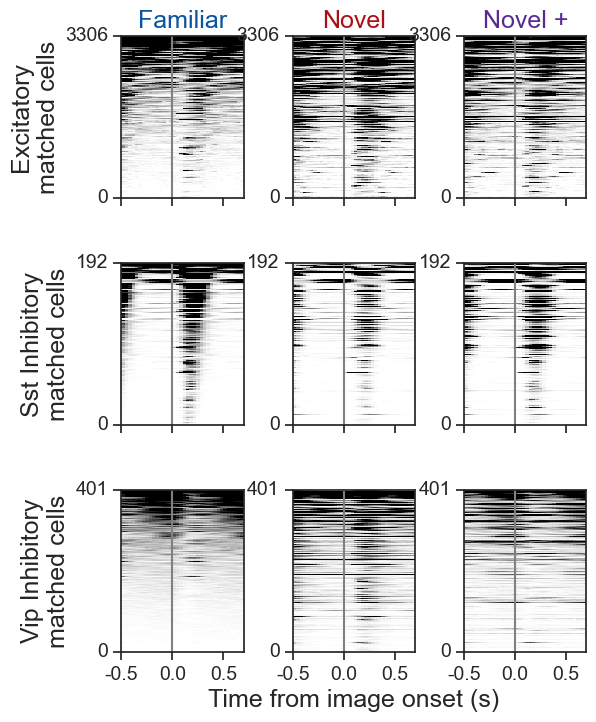

In [10]:
# Cell-matched population averages for images
matched = utilities.limit_to_cell_specimen_ids_matched_in_all_experience_levels(image_mdf)
matched = utilities.limit_to_last_familiar_second_novel_active(matched)

xlim_seconds = [-0.5, 0.7]

timestamps = image_mdf.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'

ppf.plot_response_heatmaps_for_conditions(
    matched, timestamps, data_type, 'all', row_condition, col_condition, 
    col_to_sort_by='mean_baseline', suptitle='Matched cells - Images', exp_to_match='Familiar',
    xlabel='Time from image onset (s)', matched_cells_table=matched_cells_table,
    xlim_seconds=xlim_seconds, match_cells=True, cbar=False, plot_epochs=False,
    save_dir=save_dir, folder='population_activity', suffix='_matched_cells_images', ax=None)

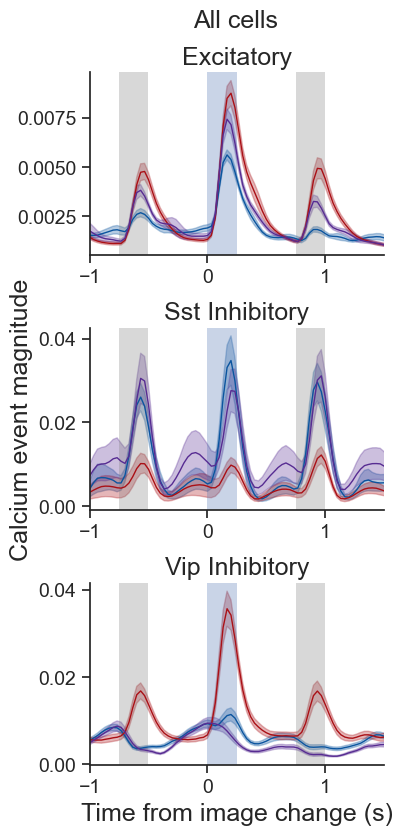

In [11]:
# population averages for changes
xlim_seconds = [-1., 1.5]

suffix = '_changes_all_cells'

ax = ppf.plot_population_averages_for_conditions(
    change_mdf, data_type, 'changes', axes_column, hue_column,
    ylabel='Calcium event magnitude', sharey=False,
    horizontal=False, xlabel='Time from image change (s)',
    xlim_seconds=xlim_seconds, interval_sec=1, legend=False,
    palette=palette, ax=None, title=None, suptitle='All cells',
    save_dir=save_dir, folder='population_activity', suffix=suffix)

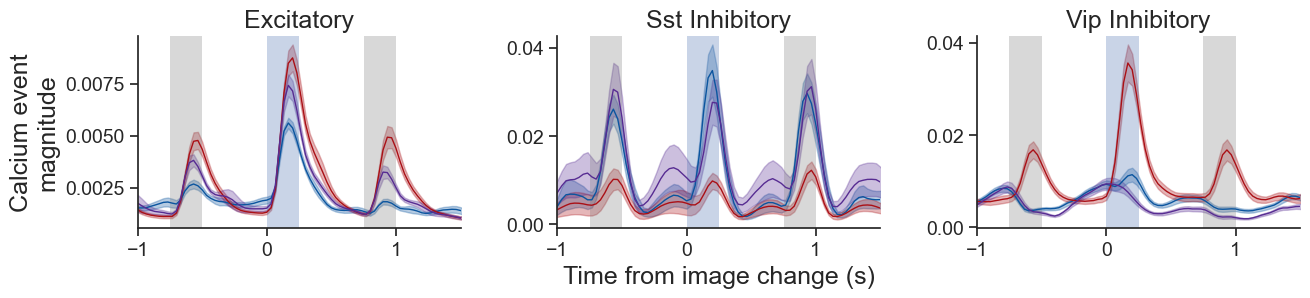

In [20]:
# population averages for changes
xlim_seconds = [-1., 1.5]

suffix = '_changes_all_cells'

ax = ppf.plot_population_averages_for_conditions(
    change_mdf, data_type, 'changes', axes_column, hue_column,
    ylabel='Calcium event\nmagnitude', sharey=False,
    horizontal=True, xlabel='Time from image change (s)',
    xlim_seconds=xlim_seconds, interval_sec=1, legend=False,
    palette=palette, ax=None, title=None, suptitle='',
    save_dir=save_dir, folder='population_activity', suffix=suffix)

array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\ncells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\ncells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\ncells'>,
       <Axes: xlabel='Time from image change (s)'>, <Axes: >],
      dtype=object)

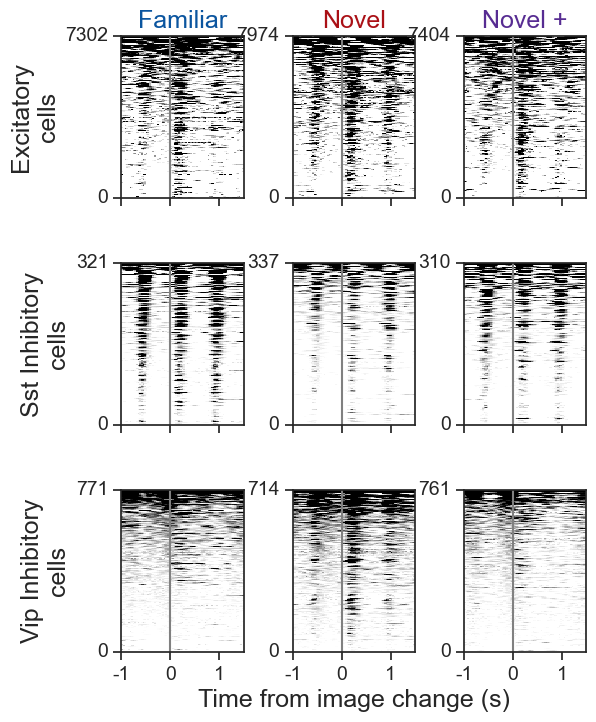

In [12]:

timestamps = change_mdf.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'

ppf.plot_response_heatmaps_for_conditions(
    change_mdf, timestamps, data_type, 'all', row_condition, col_condition, 
    col_to_sort_by='mean_baseline', suptitle='All cells', exp_to_match='Familiar',
    xlabel='Time from image change (s)', matched_cells_table=None,
    xlim_seconds=[-1, 1.5], match_cells=False, cbar=False, plot_epochs=False,
    save_dir=save_dir, folder='population_activity', suffix='_all', ax=None)

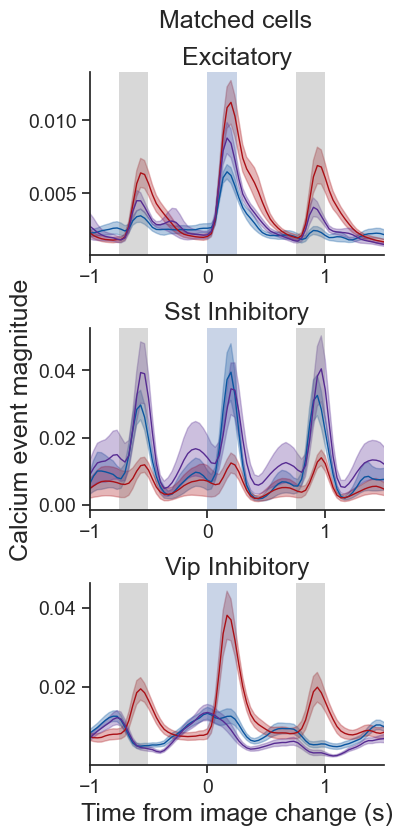

In [13]:
# Cell-matched population averages for changes
matched_changes = utilities.limit_to_cell_specimen_ids_matched_in_all_experience_levels(change_mdf)
xlim_seconds = [-1., 1.5]

suffix = '_changes_matched'

ax = ppf.plot_population_averages_for_conditions(
    matched_changes, data_type, 'changes', axes_column, hue_column,
    ylabel='Calcium event magnitude', sharey=False,
    horizontal=False, xlabel='Time from image change (s)',
    xlim_seconds=xlim_seconds, interval_sec=1, legend=False,
    palette=palette, ax=None, title=None, suptitle='Matched cells',
    save_dir=save_dir, folder='population_activity', suffix=suffix)

array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\nmatched cells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\nmatched cells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\nmatched cells'>,
       <Axes: xlabel='Time from image change (s)'>, <Axes: >],
      dtype=object)

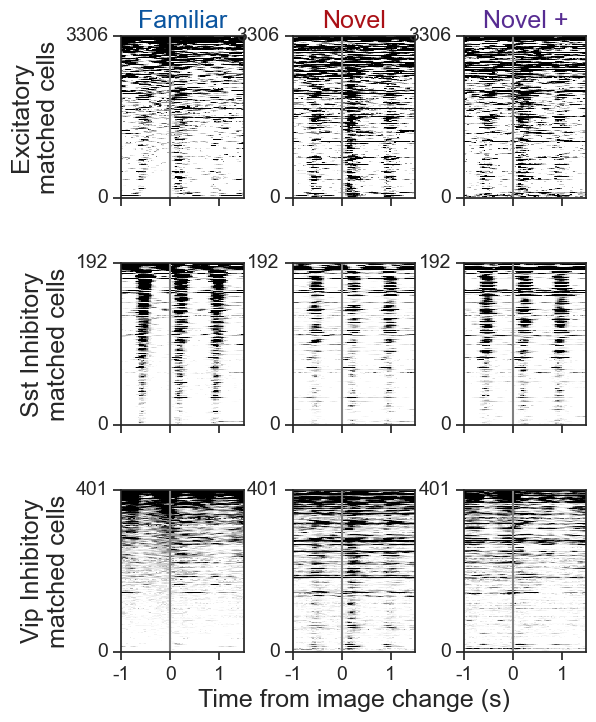

In [14]:
# Cell-matched response heatmaps for images
matched = utilities.limit_to_cell_specimen_ids_matched_in_all_experience_levels(change_mdf)
matched = utilities.limit_to_last_familiar_second_novel_active(matched)

timestamps = change_mdf.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'

ppf.plot_response_heatmaps_for_conditions(
    matched, timestamps, data_type, 'all', row_condition, col_condition, 
    col_to_sort_by='mean_baseline', suptitle='Matched cells - Images', exp_to_match='Familiar',
    xlabel='Time from image change (s)', matched_cells_table=matched_cells_table,
    xlim_seconds=[-1, 1.5], match_cells=True, cbar=False, plot_epochs=False,
    save_dir=save_dir, folder='population_activity', suffix='_matched', ax=None)

#### Fraction responsive cells

Percentage of cells with significant responses to non-change images, image changes,
and image omissions, across experience levels for each cell type. Responsiveness is
defined as having significantly larger activity during stimulus events compared to
a shuffled distribution from the pre-session gray screen period, for at least 10%
of all events. Also includes fraction responsive split by imaging depth and
cohort. Corresponds to PPT Figure S6 panels E-F and S8 panel K.

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/

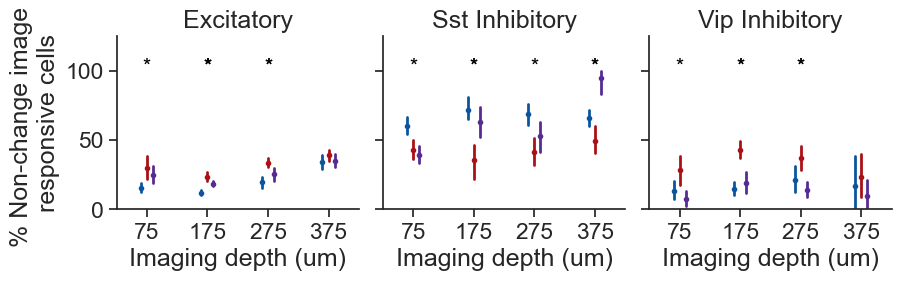

In [15]:
df = each_image_mdf[(each_image_mdf.pref_stim==True) & (each_image_mdf.is_change==False)]
fraction_responsive = ppf.get_fraction_responsive_cells(df, conditions=['cell_type', 'experience_level', 'ophys_container_id', 'ophys_experiment_id'],
                                                        responsiveness_threshold=0.1)
fraction_responsive = fraction_responsive.reset_index()
fraction_responsive = fraction_responsive.merge(platform_experiments[['ophys_container_id', 'binned_depth', 'imaging_depth']], on='ophys_container_id')
fraction_responsive = fraction_responsive.drop_duplicates(subset=['ophys_container_id', 'ophys_experiment_id'])
fraction_responsive['percent_responsive'] = fraction_responsive['fraction_responsive']*100

depths = np.sort(fraction_responsive.binned_depth.unique())

cell_types = utils.get_cell_types()
figsize = (10, 2.25)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)
ax = ax.ravel()
for i, cell_type in enumerate(cell_types): 
    data = fraction_responsive[fraction_responsive.cell_type==cell_type]
    ax[i] = sns.pointplot(data=data,
                    x='binned_depth', y='percent_responsive', hue='experience_level', linestyle='none', order=depths,
                    markers='.', markersize=4, err_kws={'linewidth': 2}, palette=experience_level_colors, dodge=0.2, ax=ax[i])
    ax[i].set_title(cell_type)
    # ax[i].legend(fontsize='xx-small')
    ax[i].get_legend().remove()
    ax[i].set_xlabel('Imaging depth (um)')
    ax[i].set_ylabel('% Non-change image \nresponsive cells')
    ax[i].set_ylim(0, 100)

    ax[i], stats_table = ppf.add_stats_to_plot_for_hues(data, 'percent_responsive', ax[i],
                                                            xorder=depths, x='binned_depth', hue='experience_level')
plt.subplots_adjust(wspace=0.1)

filename = 'percent_nonchange_pref_image_responsive_cells_by_depth'
utils.save_figure(fig, figsize, save_dir, folder, filename)

In [16]:
df = each_image_mdf[(each_image_mdf.pref_stim==True) & (each_image_mdf.is_change==True)]
fraction_responsive = ppf.get_fraction_responsive_cells(df, conditions=['cell_type', 'experience_level', 'ophys_container_id', 'ophys_experiment_id'],
                                                        responsiveness_threshold=0.1)
fraction_responsive = fraction_responsive.reset_index()
fraction_responsive = fraction_responsive.merge(platform_experiments[['ophys_container_id', 'binned_depth', 'imaging_depth']], on='ophys_container_id')
fraction_responsive = fraction_responsive.drop_duplicates(subset=['ophys_container_id', 'ophys_experiment_id'])
fraction_responsive['percent_responsive'] = fraction_responsive['fraction_responsive']*100

depths = np.sort(fraction_responsive.binned_depth.unique())

cell_types = utils.get_cell_types()
figsize = (10, 2.25)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)
ax = ax.ravel()
for i, cell_type in enumerate(cell_types): 
    data = fraction_responsive[fraction_responsive.cell_type==cell_type]
    ax[i] = sns.pointplot(data=data,
                    x='binned_depth', y='percent_responsive', hue='experience_level', linestyle='none', order=depths,
                    markers='.', markersize=4, err_kws={'linewidth': 2}, palette=experience_level_colors, dodge=0.2, ax=ax[i])
    ax[i].set_title(cell_type)
    # ax[i].legend(fontsize='xx-small')
    ax[i].get_legend().remove()
    ax[i].set_xlabel('Imaging depth (um)')
    ax[i].set_ylabel('% Image change\nresponsive cells')
    ax[i].set_ylim(0, 100)

    ax[i], tukey_table = ppf.add_stats_to_plot_for_hues(data, 'percent_responsive', ax[i],
                                                            xorder=depths, x='binned_depth', hue='experience_level')
plt.subplots_adjust(wspace=0.1)

filename = 'percent_pref_image_change_responsive_cells_by_depth'
utils.save_figure(fig, figsize, save_dir, folder, filename)

Error in callback <function flush_figures at 0x339697dc0> (for post_execute):


KeyboardInterrupt: 

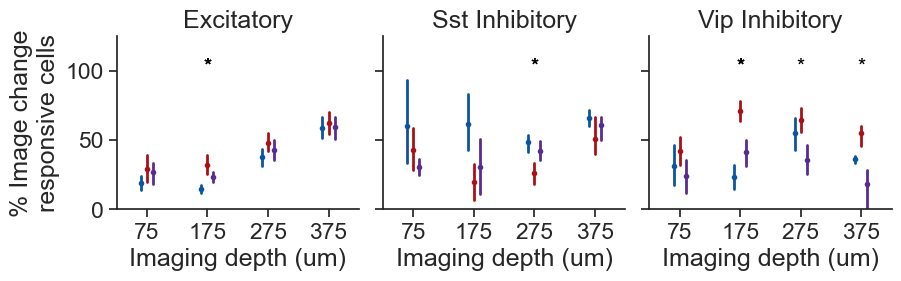

In [ ]:
df = change_mdf.copy()

# Also get fraction of responsive cells
fraction_responsive = ppf.get_fraction_responsive_cells(
    df, conditions=['cell_type', 'experience_level', 'ophys_container_id', 'ophys_experiment_id'],
    responsiveness_threshold=0.05)
fraction_responsive = fraction_responsive.reset_index()
fraction_responsive = fraction_responsive.merge(
    platform_experiments[['ophys_container_id', 'binned_depth', 'imaging_depth']],
    on='ophys_container_id')
fraction_responsive = fraction_responsive.drop_duplicates(subset=['ophys_container_id', 'ophys_experiment_id'])
fraction_responsive['percent_responsive'] = fraction_responsive['fraction_responsive'] * 100


# Plot by depth and cell type with statistical annotations
depths = np.sort(fraction_responsive.binned_depth.unique())
figsize = (10, 2.25)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)
ax = ax.ravel()

for i, cell_type in enumerate(cell_types):
    data = fraction_responsive[fraction_responsive.cell_type == cell_type]
    ax[i] = sns.pointplot(
        data=data, x='binned_depth', y='percent_responsive',
        hue='experience_level', linestyle='none', order=depths,
        markers='.', markersize=4, err_kws={'linewidth': 2},
        palette=experience_level_colors, dodge=0.2, ax=ax[i])
    ax[i].set_title(cell_type)
    ax[i].get_legend().remove()
    ax[i].set_xlabel('Imaging depth (um)')
    ax[i].set_ylabel('% Image change\nresponsive cells')
    ax[i].set_ylim(0, 100)

    # Add statistical annotations to the plot
    ax[i], tukey_table = ppf.add_stats_to_plot_for_hues(
        data, 'percent_responsive', ax[i],
        xorder=depths, x='binned_depth', hue='experience_level')

plt.subplots_adjust(wspace=0.1)
filename = 'percent_change_responsive_cells_by_depth_stats'
utils.save_figure(fig, figsize, save_dir, folder, filename)

#### Change response magnitude

array([<Axes: ylabel='Excitatory'>,
       <Axes: ylabel='Mean image change response\n\nSst Inhibitory'>,
       <Axes: ylabel='Vip Inhibitory'>], dtype=object)

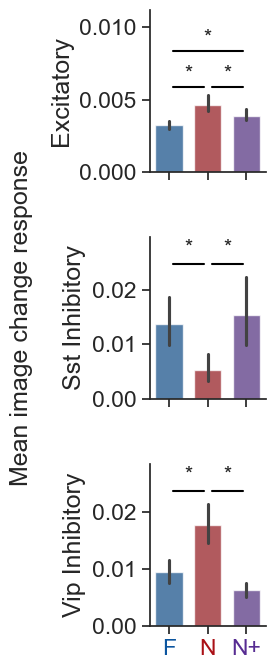

In [ ]:
metric = 'mean_response_changes'
ylabel = 'Mean image change response'

event_type = 'changes'

ylims = None #(-0.001, 0.025)

ppf.plot_metric_distribution_by_experience(metrics_table, metric, plot_type='barplot', #show_containers=True,
                                           horiz=False, add_zero_line=False, event_type=event_type, data_type=data_type,
                                           ylabel=ylabel, ylims=ylims, save_dir=save_dir, ax=None)



/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/

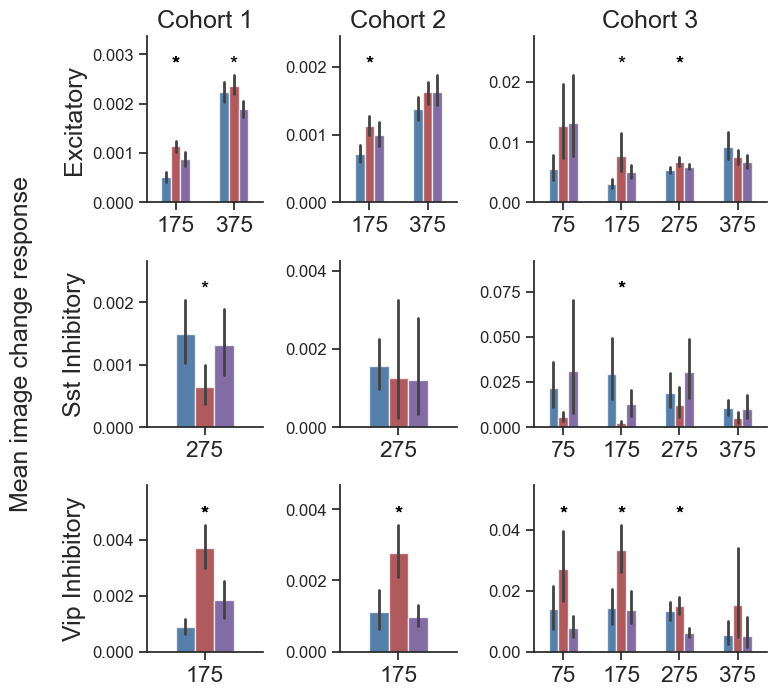

In [ ]:
metric = 'mean_response_changes'
ylabel = 'Mean image change response'
x_val = 'binned_depth'
event_type = 'changes'

ppf.plot_metric_across_cohorts(metrics_table, metric,  ylabel, x_val=x_val, plot_type='barplot', 
                               event_type=event_type, save_dir=save_dir, ax=None);

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)


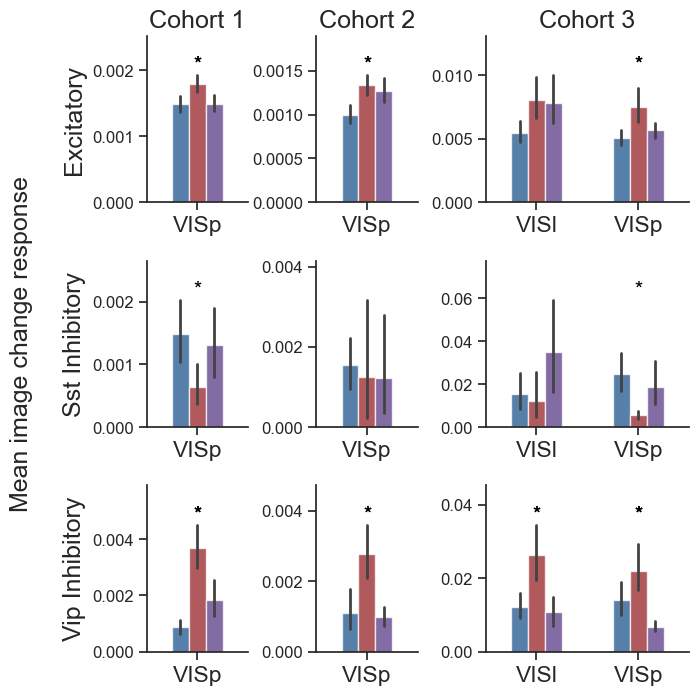

In [ ]:
metric = 'mean_response_changes'
ylabel = 'Mean image change response'
x_val = 'targeted_structure'
event_type = 'changes'

ppf.plot_metric_across_cohorts(metrics_table, metric,  ylabel, x_val=x_val, plot_type='barplot', 
                               event_type=event_type, save_dir=save_dir, ax=None);

array([<Axes: ylabel='Excitatory'>,
       <Axes: ylabel='Mean non-change image response\n\nSst Inhibitory'>,
       <Axes: ylabel='Vip Inhibitory'>], dtype=object)

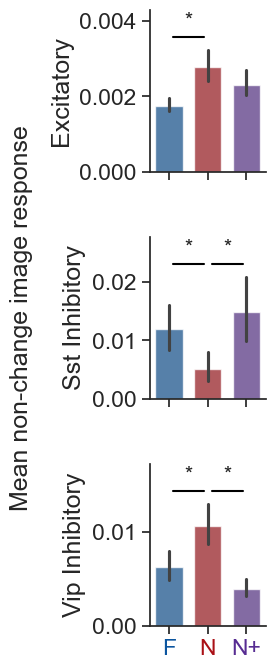

In [ ]:
metric = 'mean_response_all_images'
ylabel = 'Mean non-change image response'
event_type = 'images'
ylims = None 

ppf.plot_metric_distribution_by_experience(metrics_table, metric, plot_type='barplot', #show_containers=True,
                                           horiz=False, add_zero_line=False, event_type=event_type, data_type=data_type,
                                           ylabel=ylabel, ylims=ylims, save_dir=save_dir, ax=None)



/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/

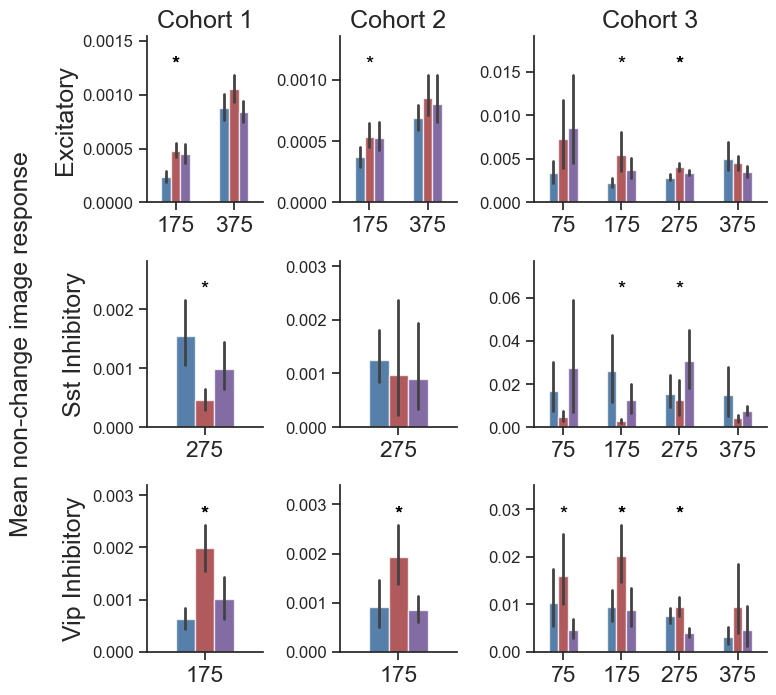

In [ ]:
metric = 'mean_response_all_images'
ylabel = 'Mean non-change image response'
event_type = 'images'
x_val = 'binned_depth'

ppf.plot_metric_across_cohorts(metrics_table, metric,  ylabel, x_val=x_val, plot_type='barplot', 
                               event_type=event_type, save_dir=save_dir, ax=None);

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)


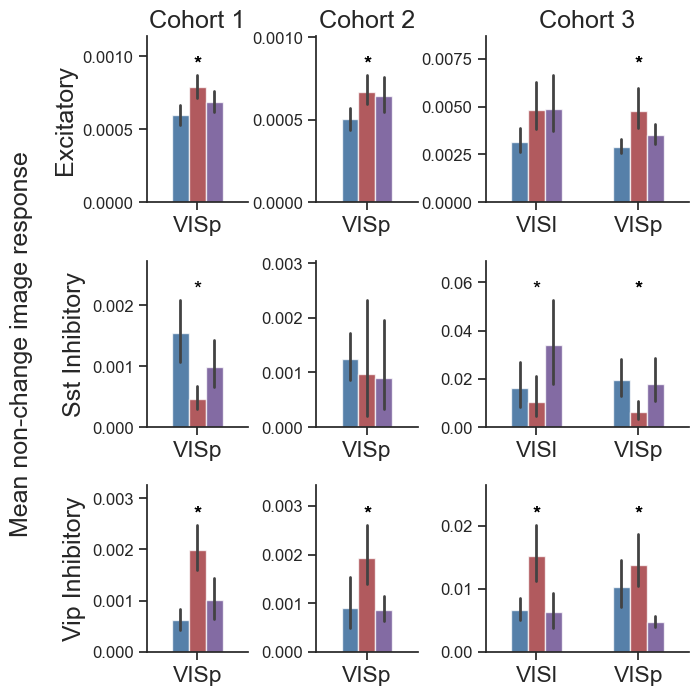

In [ ]:
metric = 'mean_response_all_images'
ylabel = 'Mean non-change image response'
event_type = 'images'
x_val = 'targeted_structure'

ppf.plot_metric_across_cohorts(metrics_table, metric,  ylabel, x_val=x_val, plot_type='barplot', 
                               event_type=event_type, save_dir=save_dir, ax=None);

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/

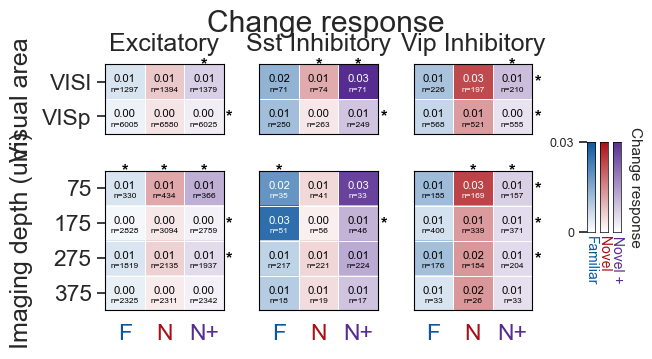

In [ ]:
if not skip_slow_plots:
    ax, stats = ppf.plot_metric_heatmap_area_and_depth_by_cell_type(
        metrics_table, metric='mean_response_changes', metric_label='Change response',
        save_dir=save_dir, event_type='changes')

In [ ]:
metrics_table

,cell_specimen_id,experience_level,ophys_experiment_id,mean_response_pref_image,reliability_pref_image,fraction_significant_p_value_gray_screen_pref_image,fano_factor_pref_image,running_modulation_pref_image,mean_response_all_images,lifetime_sparseness_images,...,layer,area_layer,date,first_novel,n_relative_to_first_novel,last_familiar,last_familiar_active,second_novel,second_novel_active,experience_exposure
0,1086490480,Familiar,795073741,0.000131,0.122168,0.011364,0.011834,1.000000,0.000066,0.348866,...,upper,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3
1,1086490397,Familiar,795073741,0.000961,0.452276,0.000000,0.019686,1.000000,0.000396,0.424478,...,upper,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3
2,1086490510,Familiar,795073741,0.004260,0.183585,0.160149,0.043784,1.000000,0.001107,0.574101,...,upper,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3
3,1086490565,Familiar,795073741,0.000229,0.738372,0.002410,0.013540,1.000000,0.000092,0.374332,...,upper,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3
4,1086490680,Familiar,795073741,0.003442,0.336522,0.072289,0.082742,1.000000,0.001172,0.441491,...,upper,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25930,1120120487,Novel +,1087825608,0.043367,0.182861,0.212406,0.338255,0.020770,0.007448,0.860475,...,lower,VISl_lower,20210303,False,2.0,False,False,False,True,Novel 3
25931,1120123643,Novel +,1087825608,0.028697,0.348907,0.276316,0.097014,0.430815,0.016435,0.233390,...,lower,VISl_lower,20210303,False,2.0,False,False,False,True,Novel 3
25932,1120124039,Novel +,1087825608,0.016337,0.223612,0.150376,0.124369,0.140823,0.003944,0.655078,...,lower,VISl_lower,20210303,False,2.0,False,False,False,True,Novel 3
25933,1120126115,Novel +,1087825608,0.001297,0.369498,0.003759,0.102116,0.508134,0.000429,0.470667,...,lower,VISl_lower,20210303,False,2.0,False,False,False,True,Novel 3


#### Change modulation index

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3519: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, y=y, x=x, order=experience_levels,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3519: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, y=y, x=x, order=experience_levels,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3519: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, y=y

array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='Change modulation'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

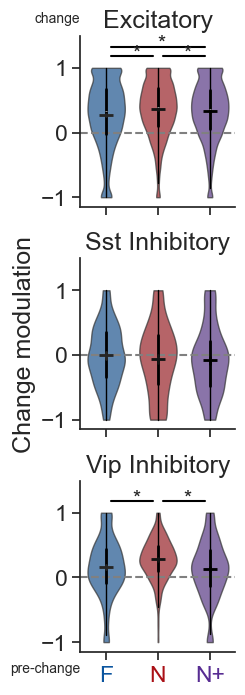

In [ ]:
metric = 'change_modulation_index'
xlabel = 'Change modulation'
event_type = 'changes'
annot = ('pre-change', 'change')
xlims = (-1.15, 1.15)

ppf.plot_modulation_index_distribution(metrics_table, metric, label=xlabel, plot_type='violinplot',
                                       lims=xlims, horiz=False, annot=annot, metric_on_y=True,
                                        abbreviate_exp=True, suptitle=None, fill=True, 
                                        save_dir=save_dir, suffix='', event_type='changes')


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3467: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, x=x, y=y, orient=orient,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Use

array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='Change modulation'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

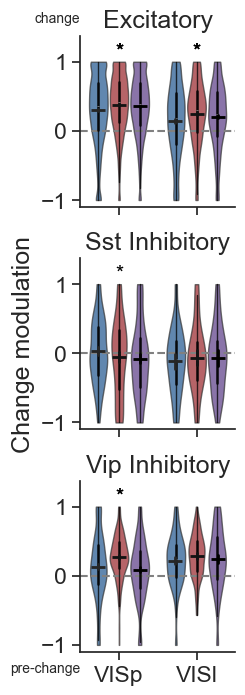

In [ ]:
metric = 'change_modulation_index'
label = 'Change modulation'
event_type = 'changes'
annot = ('pre-change', 'change')
lims = (-1.1, 1.1)

ppf.plot_modulation_index_distribution(metrics_table, metric, x_axis_col='targeted_structure', plot_type='violinplot',
                                       label=label, lims=lims, horiz=False, annot=annot, fill=True,
                                        abbreviate_exp=True, suptitle=None, save_dir=save_dir, suffix='', event_type='changes')

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3467: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, x=x, y=y, orient=orient,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Use

array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='Change modulation'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

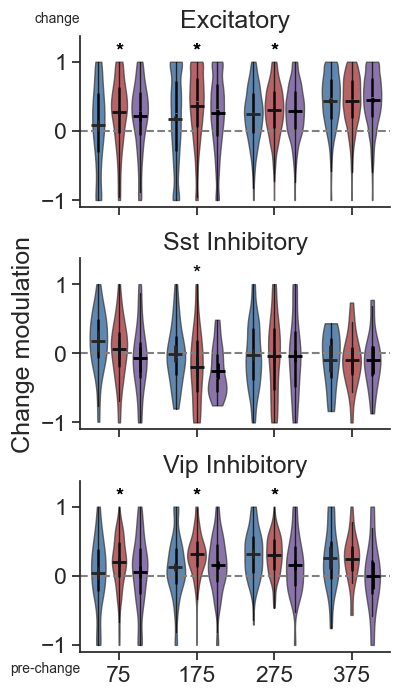

In [ ]:
metric = 'change_modulation_index'
label = 'Change modulation'
event_type = 'changes'
annot = ('pre-change', 'change')
lims = (-1.1, 1.1)

ppf.plot_modulation_index_distribution(metrics_table, metric, x_axis_col='binned_depth', plot_type='violinplot',
                                       label=label, lims=lims, horiz=False, annot=annot, fill=True,
                                    metric_on_y=True, abbreviate_exp=True, suptitle=None, save_dir=save_dir, suffix='', event_type='changes')

#### Area and depth heatmaps

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/

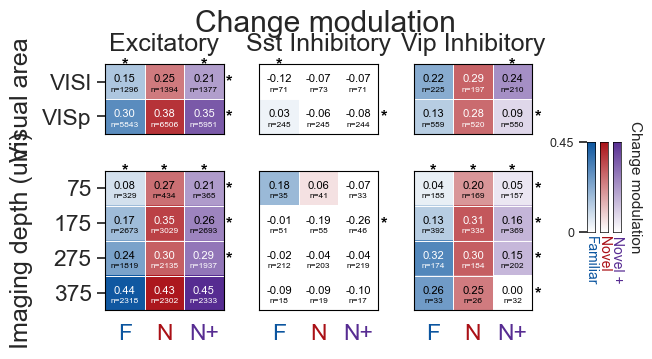

In [ ]:
if not skip_slow_plots:
    ax, stats = ppf.plot_metric_heatmap_area_and_depth_by_cell_type(
        metrics_table, metric='change_modulation_index', metric_label='Change modulation',
        event_type='changes', save_dir=save_dir)

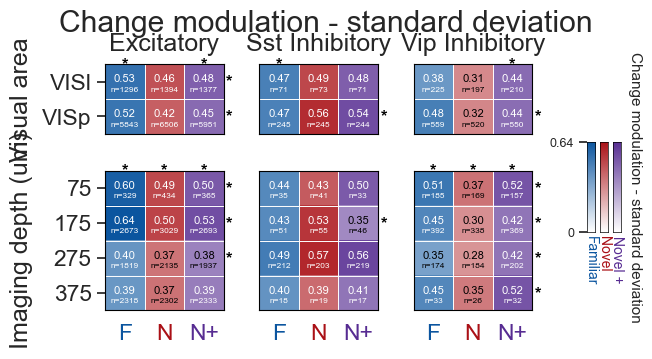

In [ ]:
if not skip_slow_plots:
    ax, stats = ppf.plot_metric_heatmap_area_and_depth_by_cell_type(
        metrics_table, metric='change_modulation_index', metric_label='Change modulation - standard deviation',
        aggregate='std', save_dir=save_dir, event_type='changes')

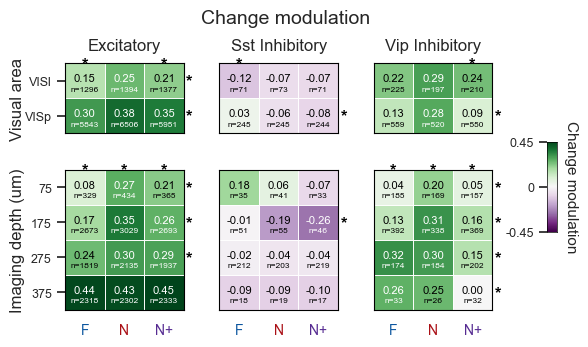

In [ ]:
if not skip_slow_plots:
    ax, stats = ppf.plot_bidirectional_metric_heatmap_area_and_depth_by_cell_type(
        metrics_table, metric='change_modulation_index', metric_label='Change modulation',
        cmap='PRGn', save_dir=save_dir, event_type='changes'
    )

#### Experience modulation

Quantification of how neural responses change across experience levels. Includes
experience modulation index (computed as the difference in mean response between
two experience levels divided by the sum) for each cell, shown as distributions
per cell type. Also shows mean image change response magnitude across cohorts,
depths, and cortical areas, and the change modulation index (response to image
changes minus response to non-change images, over the sum) split by area and
depth. Corresponds to PPT Figure S6 panels I-N.

array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}>,
       <Axes: title={'center': 'Vip Inhibitory'}, xlabel='Experience modulation'>],
      dtype=object)

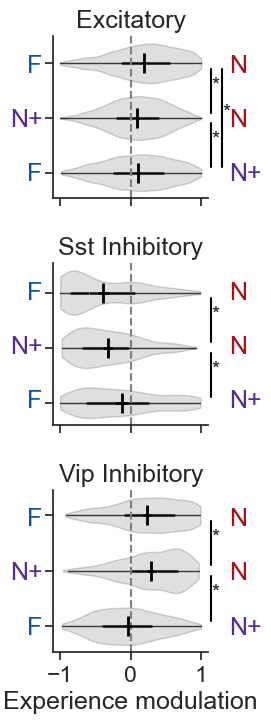

In [ ]:
metric = 'mean_response'
event_type = 'images'
xlabel = 'Experience modulation'

ppf.plot_experience_modulation_index_annotated_by_cell_type(image_mdf, event_type, metric, platform_cells_table,
                                                            xlims=(-1.1, 1.1), xlabel=xlabel,
                                                            all_comparisons=True, horiz=False,
                                                            suptitle=None, suffix='', save_dir=None, ax=None)

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:4162: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_yticklabels([cell_type[:3] for cell_type in cell_types])
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:4162: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_yticklabels([cell_type[:3] for cell_type in cell_types])
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:4162: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_yticklabels([cell_type[:3] for cell_type in cell_types])


array([<Axes: title={'center': 'Novel vs. Familiar'}>,
       <Axes: title={'center': 'Novel vs. Novel +'}>,
       <Axes: title={'center': 'Novel + vs. Familiar'}, xlabel='Experience modulation'>],
      dtype=object)

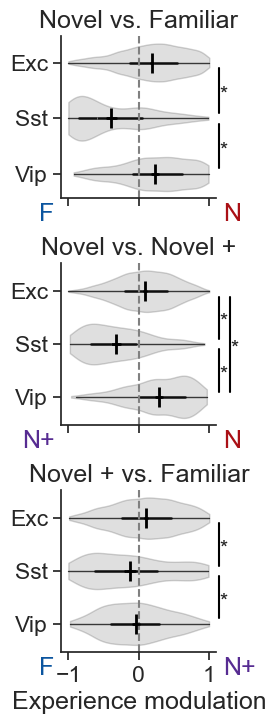

In [ ]:
metric = 'mean_response'
event_type = 'images'
xlabel = 'Experience modulation'

ppf.plot_experience_modulation_index_annotated(
    image_mdf, event_type, metric, platform_cells_table,
    horiz=False, xlims=(-1.1, 1.1), xlabel='Experience modulation',
    suffix='_images_modulation', save_dir=save_dir,)

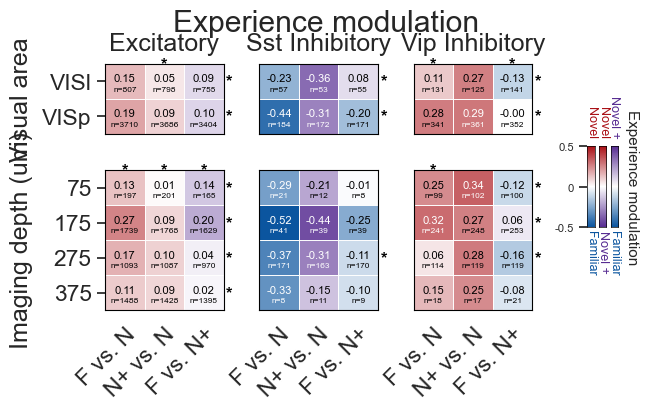

In [ ]:
if not skip_slow_plots:
    metric = 'mean_response'
    event_type = 'images'
    xlabel = 'Experience modulation'

    ax, stats = ppf.plot_experience_modulation_heatmap_area_and_depth_by_cell_type(
        image_mdf, event_type=event_type, metric=metric,
        cells_table=platform_cells_table,
        save_dir=save_dir, folder='metric_distributions',
    )

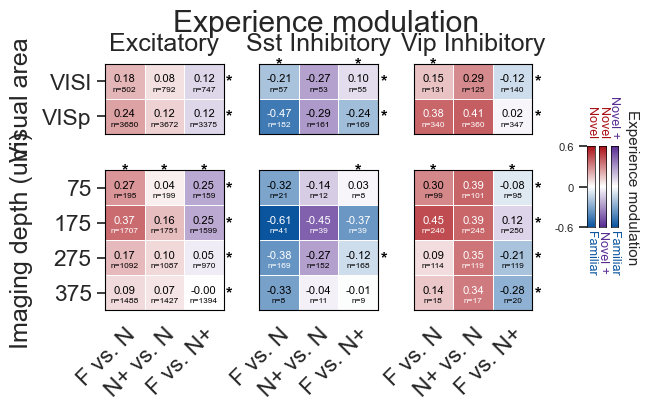

In [ ]:
if not skip_slow_plots:
    metric = 'mean_response'
    event_type = 'changes'
    xlabel = 'Experience modulation'

    ax, stats = ppf.plot_experience_modulation_heatmap_area_and_depth_by_cell_type(
        change_mdf, event_type=event_type, metric=metric,
        cells_table=platform_cells_table,
        save_dir=save_dir, folder='metric_distributions',
    )

In [ ]:
# ax3, stats_table = ppf.plot_experience_modulation_index_depth_heatmap_by_cell_type(
#     image_mdf, event_type, metric, platform_cells_table,
#     groupby_col='binned_depth', ylabel='Imaging depth (um)')

# ax3, stats_table = ppf.plot_experience_modulation_index_depth_heatmap_by_cell_type(
#     image_mdf, event_type, metric, platform_cells_table,
#     groupby_col='targeted_structure', ylabel='Visual area')


##### Experience vs change modulation 

In [ ]:
import visual_behavior.ophys.response_analysis.cell_metrics as cm

metric = 'mean_response'
exp_mod = cm.compute_experience_modulation_index_new(image_mdf, metric, platform_cells_table)
exp_mod = exp_mod.drop_duplicates(subset='cell_specimen_id')

value_vars = ['F N', 'N+ N', 'F N+']
data = exp_mod.melt(id_vars=['cell_specimen_id', 'cell_type'], var_name='comparison', value_vars=value_vars)
titles = ['Novel vs. Familiar', 'Novel vs. Novel +', 'Novel + vs. Familiar']

data.head()

,cell_specimen_id,cell_type,comparison,value
0,1086489847,Vip Inhibitory,F N,0.537837
1,1086489860,Vip Inhibitory,F N,0.480181
2,1086489869,Vip Inhibitory,F N,NaN
3,1086489882,Vip Inhibitory,F N,NaN
4,1086489891,Vip Inhibitory,F N,0.473063


In [ ]:

# def plot_modulation_index_correlation(data, x_col, y_col, xlabel, ylabel,
#                             ax=None, save_dir=None, folder=None, filename=None):
#     """
#     Plots the correlation between two modulation indices (e.g., experience modulation index and change modulation index)
#     for each cell type, including a linear best-fit line and Pearson correlation coefficient.

#     Parameters:
#     - data: DataFrame containing the modulation indices and cell types.
#     - x_col: Column name for the x-axis modulation index.
#     - y_col: Column name for the y-axis modulation index.
#     - ax: Matplotlib axis to plot on (optional).
#     - save_dir: Directory to save the figure (optional).
#     - folder: Subfolder within save_dir to save the figure (optional).
#     - filename: Name of the file to save the figure (optional).
#     """

#     import numpy as np
#     from scipy.stats import pearsonr

#     if ax is None: 
#         figsize = (2, 8)
#         fig, ax = plt.subplots(3, 1, figsize=figsize, sharex=True, sharey=True)

#     for i, cell_type in enumerate(cell_types):
#         cell_type_data = df[df.cell_type == cell_type]
#         plot_data = cell_type_data[[x_col, y_col]].dropna()

#         ax[i] = sns.kdeplot(data=plot_data, x=x_col, y=y_col, ax=ax[i])

#         # Add linear best-fit line and Pearson correlation for the plotted x/y values.
#         if len(plot_data) >= 2:
#             x = plot_data[x_col].to_numpy()
#             y = plot_data[y_col].to_numpy()

#             if np.std(x) > 0 and np.std(y) > 0:
#                 r, p = pearsonr(x, y)
#                 slope, intercept = np.polyfit(x, y, 1)
#                 x_fit = np.array([x.min(), x.max()])
#                 y_fit = slope * x_fit + intercept
#                 p_str = f"{p:.2e}" if p < 1e-3 else f"{p:.3f}"
#                 ax[i].plot(x_fit, y_fit, color='black', linestyle='--', linewidth=1.5)
#                 ax[i].set_title(f"{cell_type}\n(r={r:.2f}, p={p_str})")
#             else:
#                 ax[i].set_title(f"{cell_type}\n(r=nan, p=nan)")
#         else:
#             ax[i].set_title(f"{cell_type}\n(r=nan, p=nan)")

#         ax[i].set_ylabel('')

#     ax[2].set_xlabel(xlabel)
#     ax[1].set_ylabel(ylabel)

#     plt.subplots_adjust(hspace=0.4)
#     if save_dir and folder:
#         filename = filename or f"{y_col}_vs_{x_col}_correlation"
#         utils.save_figure(fig, figsize, save_dir, folder, filename)



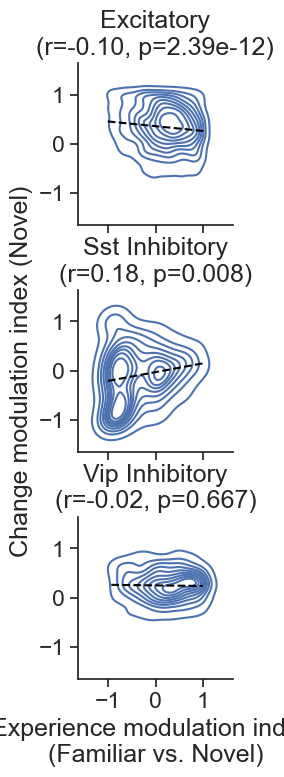

In [ ]:

exp_mod_f_n = data[data.comparison=='F N']
change_mod_n = metrics_table[metrics_table.experience_level=='Novel'][['cell_specimen_id', 'change_modulation_index']].merge(exp_mod_f_n)
df = change_mod_n.merge(exp_mod_f_n)
df = df.rename(columns={'value': 'experience_modulation_index'})

x_col = 'experience_modulation_index'
y_col = 'change_modulation_index'

xlabel = 'Experience modulation index \n(Familiar vs. Novel)'
ylabel = 'Change modulation index (Novel)'


ppf.plot_modulation_index_correlation(df, x_col, y_col, xlabel, ylabel,
                            ax=None, save_dir=None, folder=None, filename=None)

                            

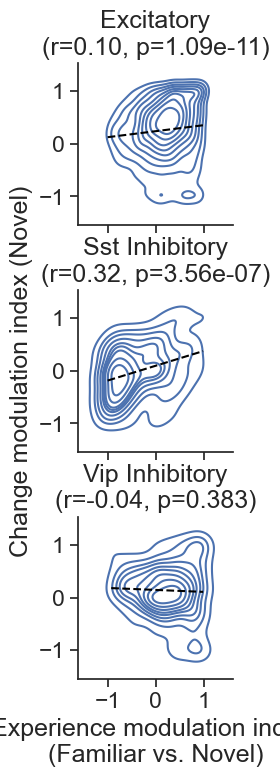

In [ ]:

exp_mod_f_n = data[data.comparison=='F N']
change_mod_n = metrics_table[metrics_table.experience_level=='Familiar'][['cell_specimen_id', 'change_modulation_index']].merge(exp_mod_f_n)
df = change_mod_n.merge(exp_mod_f_n)
df = df.rename(columns={'value': 'experience_modulation_index'})

x_col = 'experience_modulation_index'
y_col = 'change_modulation_index'

ppf.plot_modulation_index_correlation(df, x_col, y_col, xlabel, ylabel,
                            ax=None, save_dir=None, folder=None, filename=None)

                            

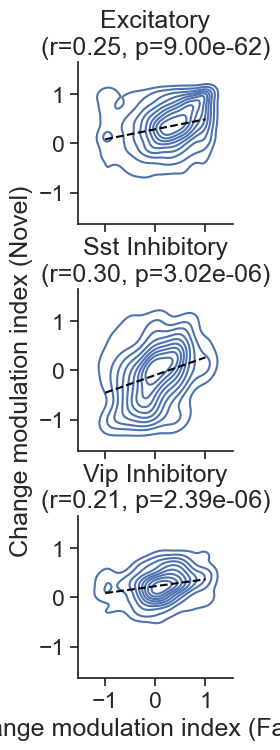

In [ ]:
change_mod_f = metrics_table[metrics_table.experience_level=='Familiar'][['cell_specimen_id', 'change_modulation_index', 'cell_type']].rename(columns={'change_modulation_index': 'change_modulation_index_familiar'})
change_mod_n = metrics_table[metrics_table.experience_level=='Novel'][['cell_specimen_id', 'change_modulation_index', 'cell_type']].rename(columns={'change_modulation_index': 'change_modulation_index_novel'})
df = change_mod_n.merge(change_mod_f, on=['cell_specimen_id', 'cell_type'])

x_col = 'change_modulation_index_familiar'
y_col = 'change_modulation_index_novel'
xlabel='Change modulation index (Familiar)'
ylabel='Change modulation index (Novel)'

ppf.plot_modulation_index_correlation(df, x_col, y_col, xlabel, ylabel,
                            ax=None, save_dir=None, folder=None, filename=None)

                            

## SVM decoding (for S6 panel I & S7 panel G)
Loads the aggregated all_sess SVM decoding data and builds the across-project-code aggregated standalone plots. The labeled df / time axis / window metrics are stashed in `svm_agg` and reused by the S6 and S7 composite cells below.

[ok] decode_changes_from_nochanges / VisualBehavior: all_sess_events_svm_decode_changes_from_nochanges_equalTrs_frames-15to22_VisualBehavior_20220113_202511.h5
[ok] decode_changes_from_nochanges / VisualBehaviorTask1B: all_sess_events_svm_decode_changes_from_nochanges_equalTrs_frames-15to22_VisualBehaviorTask1B_20220113_202313.h5
[ok] decode_changes_from_nochanges / VisualBehaviorMultiscope: all_sess_events_svm_decode_changes_from_nochanges_equalTrs_frames-5to7_VisualBehaviorMultiscope_20220114_110349.h5
[ok] decode_baseline_from_nobaseline / VisualBehavior: all_sess_events_svm_decode_baseline_from_nobaseline_equalTrs_frames-15to22_VisualBehavior_20220113_202737.h5
[ok] decode_baseline_from_nobaseline / VisualBehaviorTask1B: all_sess_events_svm_decode_baseline_from_nobaseline_equalTrs_frames-15to22_VisualBehaviorTask1B_20220113_203011.h5
[ok] decode_baseline_from_nobaseline / VisualBehaviorMultiscope: all_sess_events_svm_decode_baseline_from_nobaseline_equalTrs_frames-5to7_VisualBehavi

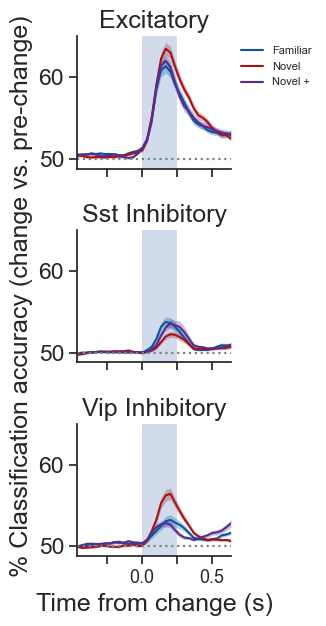

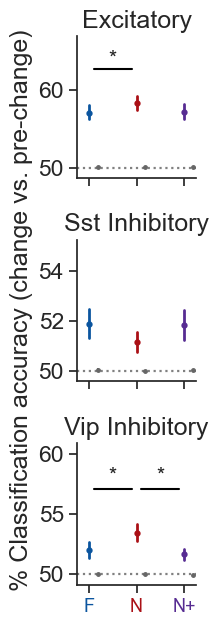

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:10903: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(Mp, 0)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:10903: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(Mp, 0)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:10903: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(Mp, 0)
/opt/miniconda3/e

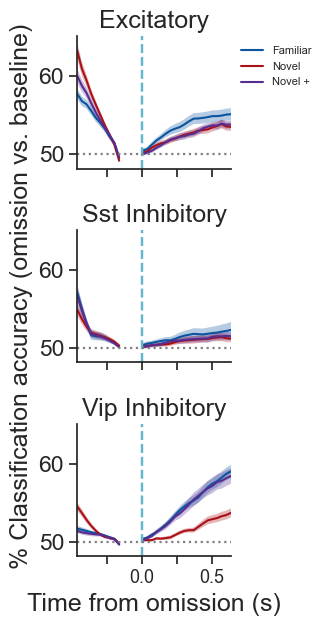

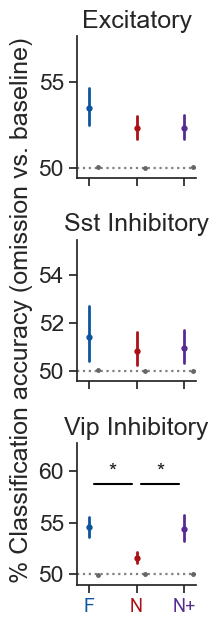

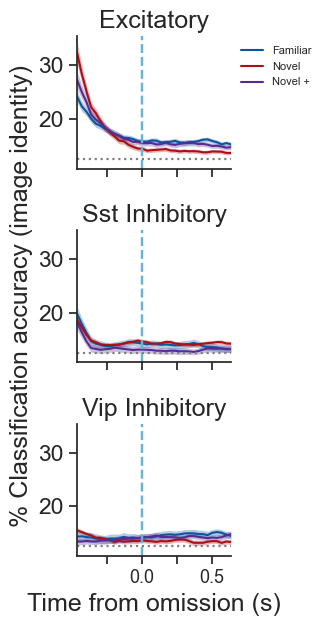

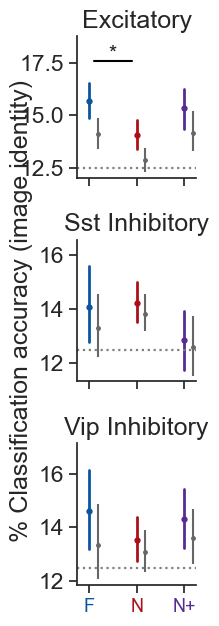

In [ ]:
# ============================================================================
# SVM decoding (aggregated across project codes)
# Loads the all_sess SVM decoding aggregates and builds the across-project-code
# aggregated standalone plots for:
#   decode_changes_from_nochanges   -> Figure S6 panel I (change vs. no-change)
#   decode_baseline_from_nobaseline -> Figure S7 panel G (omission vs. gray)
#   decode_next_image_from_omissions -> Figure S8 panel F (image identity)
# The labeled df / common time axis / window metrics are stashed in `svm_agg`
# and reused by the S6 and S7 composite cells below.
# Mirrors load_svm_decoding_results.ipynb.
# ============================================================================
import re
import glob
import importlib
import matplotlib.pyplot as plt
importlib.reload(ppf)   # pick up the decoding functions added to platform_paper_figures.py

svm_project_codes = ['VisualBehavior', 'VisualBehaviorTask1B', 'VisualBehaviorMultiscope']
_svm_dir = os.path.join(loading.get_platform_analysis_cache_dir(), 'visual_behavior_ophys_decoding')
svm_metrics_dir = os.path.join(_svm_dir, 'window_metrics')

_SVM_PC_RE = re.compile(r'_(VisualBehaviorMultiscope|VisualBehaviorTask1B|VisualBehavior)_\d{8}_\d{6}\.h5$')
_SVM_TS_RE = re.compile(r'_(\d{8})_(\d{6})\.h5$')


def _svm_project_code(b):
    m = _SVM_PC_RE.search(b)
    return m.group(1) if m else None


def _svm_timestamp(b):
    m = _SVM_TS_RE.search(b)
    return (m.group(1) + m.group(2)) if m else ''


def find_svm_events_file(decoding_type, project_code):
    """Latest standard all_sess events aggregate for a (decoding_type, project_code)."""
    keep = []
    for f in glob.glob(os.path.join(_svm_dir, 'all_sess_events_svm_%s_*.h5' % decoding_type)):
        b = os.path.basename(f)
        if 'matched_cells' in b or 'sameNumNeurons' in b:
            continue
        if _svm_project_code(b) != project_code:
            continue
        keep.append(f)
    keep.sort(key=lambda f: _svm_timestamp(os.path.basename(f)))
    return keep[-1] if keep else None


svm_decoding_types = ['decode_changes_from_nochanges', 'decode_baseline_from_nobaseline',
                      'decode_next_image_from_omissions']  # last = S8 panel F (image identity)
svm_results, svm_input_vars = {}, {}
for _dt in svm_decoding_types:
    svm_results[_dt], svm_input_vars[_dt] = {}, {}
    for _pc in svm_project_codes:
        _fp = find_svm_events_file(_dt, _pc)
        if _fp is None:
            print('[missing] %s / %s' % (_dt, _pc))
            continue
        svm_results[_dt][_pc] = pd.read_hdf(_fp, key='all_sess')
        try:
            svm_input_vars[_dt][_pc] = pd.read_hdf(_fp, key='input_vars')
        except KeyError:
            svm_input_vars[_dt][_pc] = None
        print('[ok] %s / %s: %s' % (_dt, _pc, os.path.basename(_fp)))

# aggregate across project codes; build standalone figures; stash for the composites
svm_agg = {}
for _dt in svm_decoding_types:
    _combined, _t = ppf.resample_decoding_across_projects(
        svm_results, svm_input_vars, _dt, svm_project_codes)
    _labeled = ppf.add_decoding_labels(_combined, platform_experiments)
    _wm = ppf.get_decoding_window_metrics(
        _labeled, _dt, _t, metrics_dir=svm_metrics_dir, tag='aggregated', recompute=False)
    svm_agg[_dt] = dict(labeled=_labeled, t=_t, wm=_wm)
    ppf.plot_decoding_figures(_combined, _dt, platform_experiments, time_axis=_t,
                              metrics_dir=svm_metrics_dir, recompute_metrics=False)
    plt.show()


## Figure S6 composite (assembled)
Extended analysis of image change related activity.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/

OVERLAP: axes of panel "J" intrudes into panel "K" (left gutter)


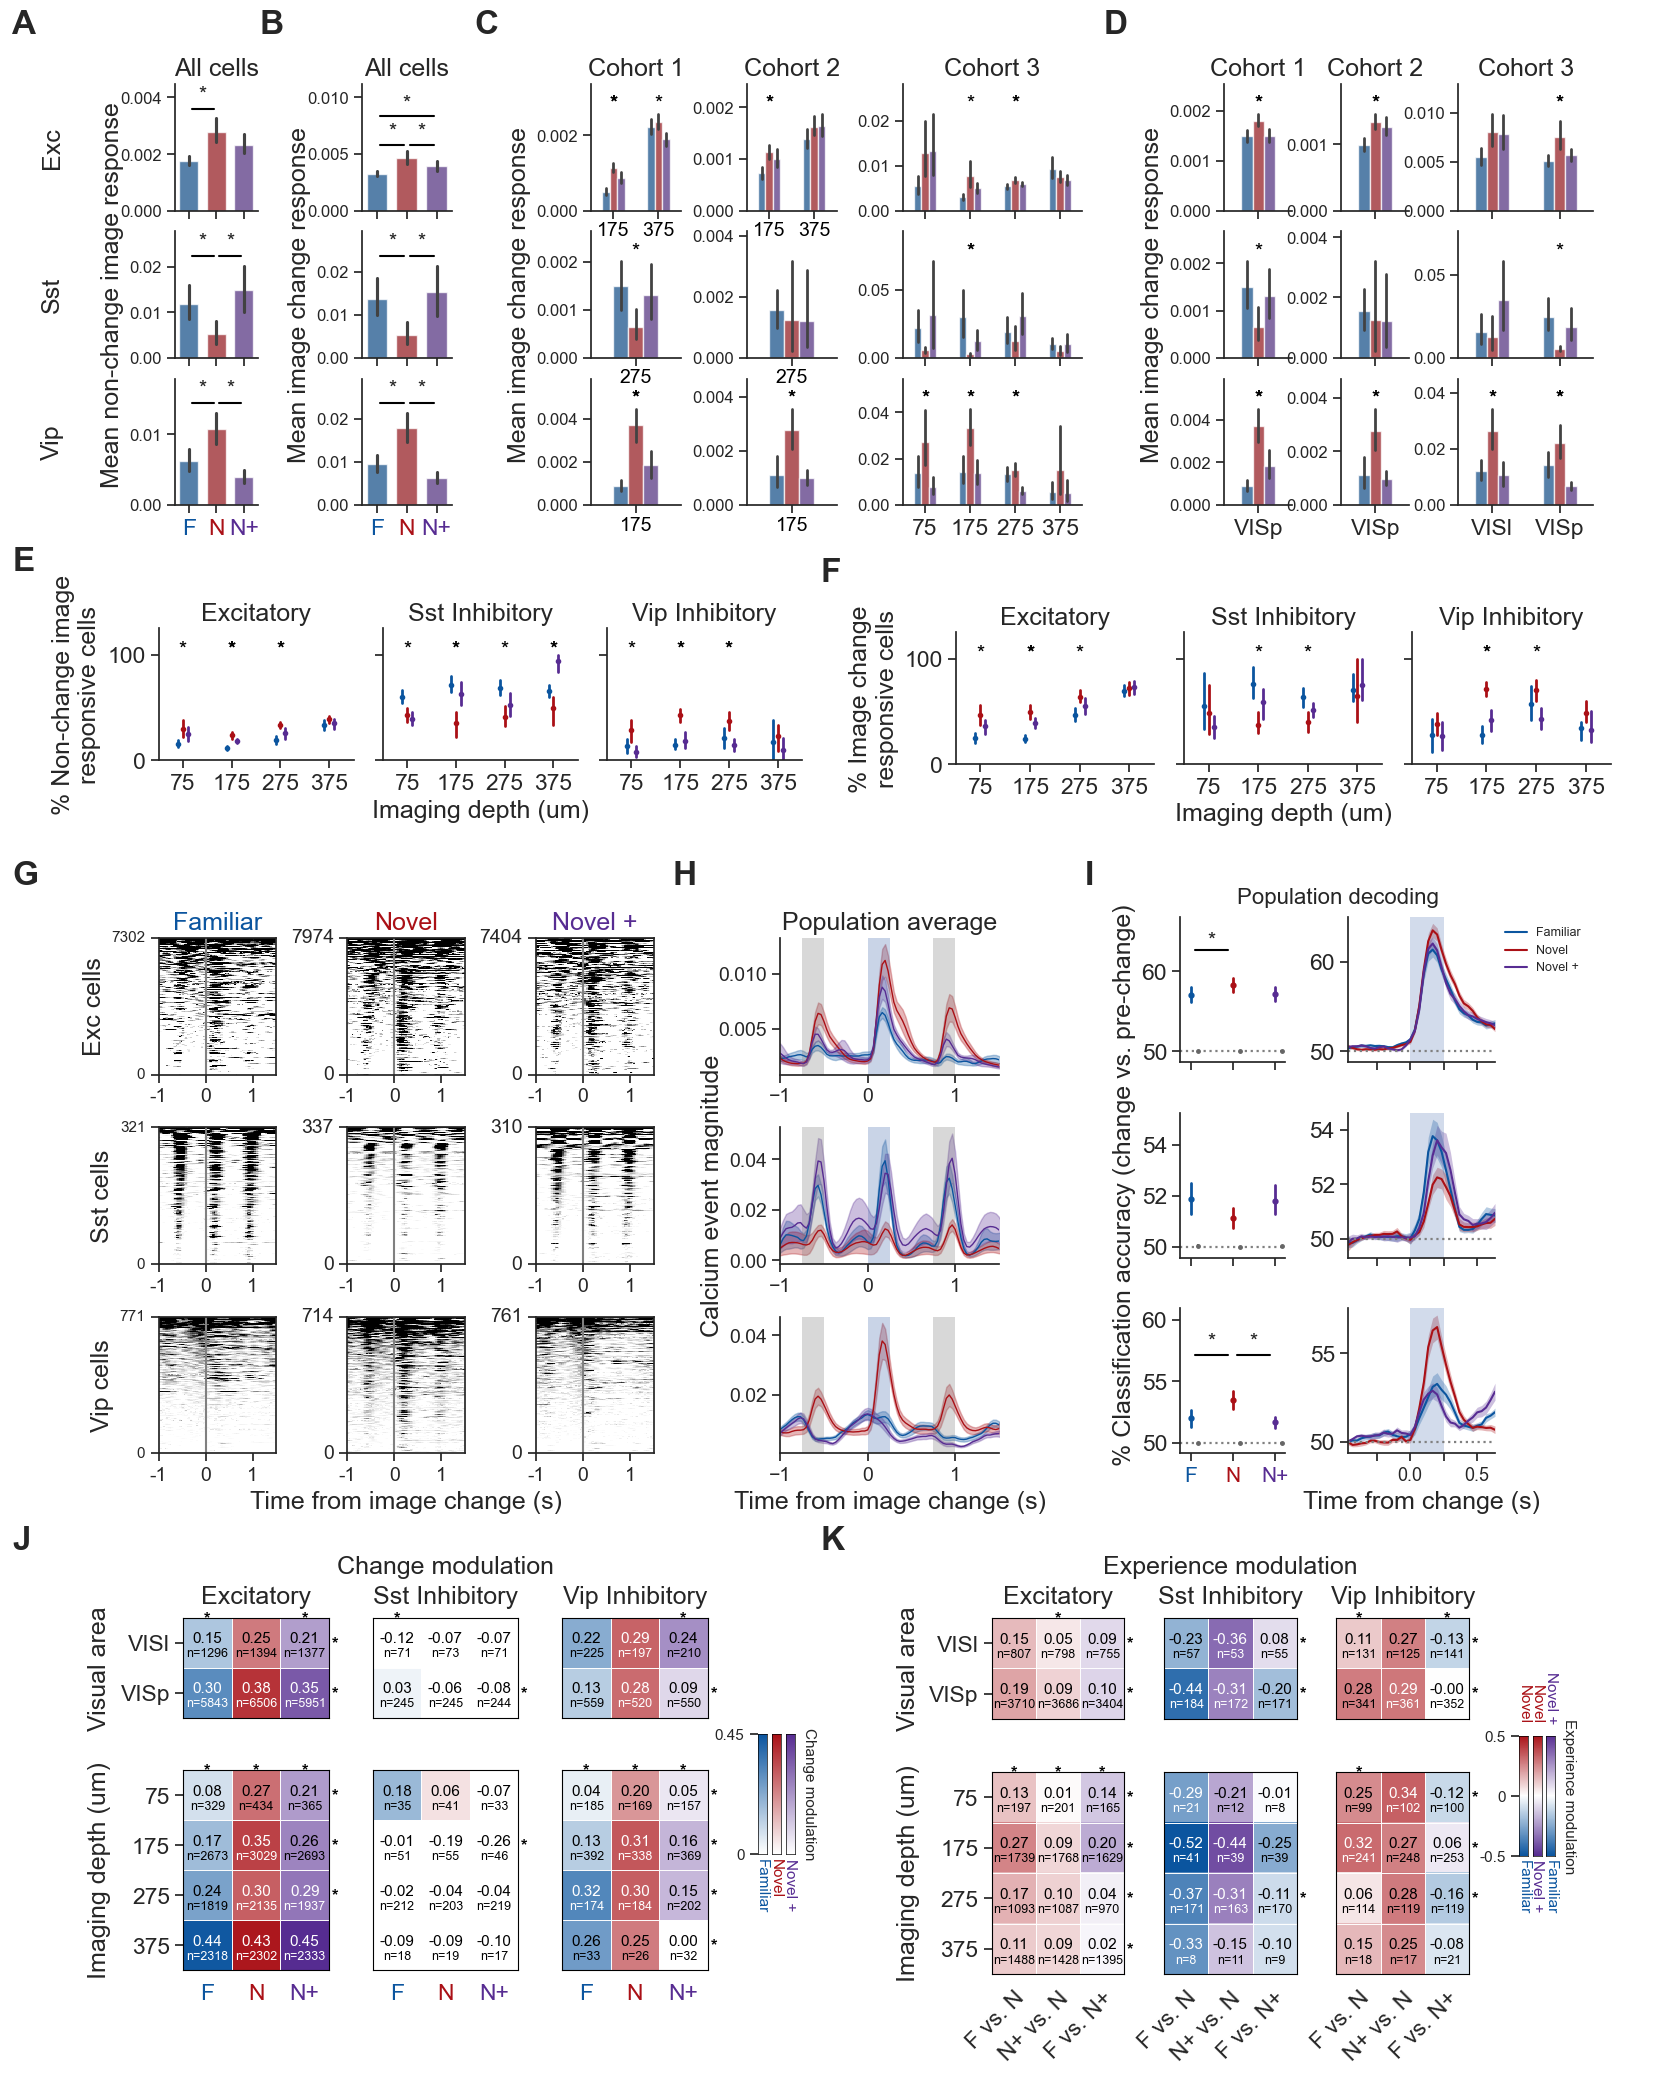

In [ ]:
# ==========================================================================
# Figure S6 composite  (Extended analysis of image change related activity)
# v10: A narrower, B wider, E/F taller, J/K down+wider. (v9: reverted figure height; J/K plots WIDER via main_width_ratios (not taller);
# A wider, B narrower; E/F down; G/H taller. (was v8: figure taller (23.08") with all extra height given to J/K (rows 1-3 keep
# absolute heights). A narrower; A first/third y-labels get a trailing newline;
# B wider. E/F taller + letters up. G/H letters down; G left spine aligned with
# A/E (decoration 82). J/K much larger.
# NOTE: restart kernel / re-run imports so the suptitle-offset change loads.
# ==========================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from visual_behavior.visualization.panel_grid import (
    fig_setup, panel, show_label_gutters, check_label_overlap,
    auto_fit_bottom, snug_left_to_gutter, snug_top_to_gutter)

sns.set_context('notebook', font_scale=1.5)

FIGSIZE = (16.5, 19.58)
REGIONS = {
    'A': [0.0, 0.15, 0.0, 0.268], 'B': [0.15, 0.273, 0.0, 0.268],
    'C': [0.283, 0.651, 0.0, 0.268], 'D': [0.667, 0.963, 0.0, 0.268],
    'E': [0.0, 0.485, 0.278, 0.413], 'F': [0.49, 0.97, 0.28, 0.415],
    'G': [0.0, 0.39, 0.436, 0.766], 'H': [0.4, 0.6036, 0.436, 0.766],
    'I': [0.65, 0.90, 0.437, 0.766],
    'J': [0.0, 0.55, 0.778, 0.998], 'K': [0.49, 1.4, 0.778, 1.0],
}
CT = utils.get_cell_types()
WSPACE_CD, WSPACE_EF, WSPACE_G = 0.55, 0.15, 0.6
LEFT_MARGIN_DEC = 82   # shared left decoration (pt) for E/G left spines
A_LEFT_DEC = 90        # A starts further right (thinner; more gap to its text annotations)


def _hide_inner_xticklabels(grid):
    rows = grid if isinstance(grid[0], (list, tuple, np.ndarray)) else [[a] for a in grid]
    for r, row in enumerate(rows):
        if r < len(rows) - 1:
            for a in row:
                a.tick_params(labelbottom=False)


def _single_metric_ylabel(grid, metric_label):
    rows = grid if isinstance(grid[0], (list, tuple, np.ndarray)) else [[a] for a in grid]
    for row in rows:
        for a in row:
            a.set_ylabel('')
    rows[len(rows) // 2][0].set_ylabel(metric_label)


def _cohort_width_ratios(x_val):
    e = metrics_table[metrics_table.cell_type == 'Excitatory']
    return [len(np.sort(e[e.project_code == pc][x_val].dropna().unique()))
            for pc in metrics_table.project_code.unique()]

def _annotate_cohort_xvals(grid, x_val, rows=(0, 1, 2), cols=(0, 1), fontsize=14, color='k', dy=-8):
    # Cohorts 1 & 2 use different depths per cell type, so each subplot's x-tick labels are
    # blanked (un-hiding them would force inter-row whitespace) and the depth is printed in the
    # x-tick-label position (just below the axis) instead -- consistent across all three rows.
    # Categories come from the data (tick-label text reads back blank before the first draw).
    cts = utils.get_cell_types()
    pcs = list(metrics_table.project_code.unique())   # column order matches plot_metric_across_cohorts
    for _r in rows:
        for _c in cols:
            _ax = grid[_r][_c]
            _ax.set_zorder(5 - _r)               # raise upper rows so their labels draw over the axis below
            _ax.tick_params(labelbottom=False)   # blank x-tick labels; the annotation replaces them
            _data = metrics_table[(metrics_table.cell_type == cts[_r]) &
                                  (metrics_table.project_code == pcs[_c])]
            for _xpos, _cat in enumerate(np.sort(_data[x_val].unique())):   # seaborn category positions = 0,1,2,...
                if isinstance(_cat, float) and np.isnan(_cat):
                    continue
                try:
                    _lab = str(int(round(float(_cat))))     # depth -> integer um
                except (ValueError, TypeError):
                    _lab = str(_cat)                        # area -> name
                _an = _ax.annotate(_lab, xy=(_xpos, 0), xycoords=('data', 'axes fraction'),
                                   xytext=(0, dy), textcoords='offset points',
                                   ha='center', va='top', fontsize=fontsize, color=color, zorder=10)
                _an.set_clip_on(False)


ts_change = change_mdf.trace_timestamps.values[0]
fig = plt.figure(figsize=FIGSIZE)
fig_setup(fig)

# ---- A: mean non-change image response (3x1; cell type each row, metric on MIDDLE) ----
axA = panel(fig, REGIONS['A'][:2], REGIONS['A'][2:], 'A', has_title=True, dim=(3, 1),
            decoration_pt=(A_LEFT_DEC, 0))
ppf.plot_metric_distribution_by_experience(
    metrics_table, 'mean_response_all_images', event_type='images', data_type=data_type,
    plot_type='barplot', horiz=False, add_zero_line=False, ylabel='Mean non-change image response',
    ylims=None, save_dir=None, ax=axA)
for a in axA:
    a.set_ylabel('')
axA[1].set_ylabel('Mean non-change image response')
axA[0].set_title('All cells')
_hide_inner_xticklabels(axA)
for a in axA:
    a.tick_params(axis='y', labelsize=12)

# ---- B: mean image change response (3x1; single metric ylabel) ----
axB = panel(fig, REGIONS['B'][:2], REGIONS['B'][2:], 'B', has_title=True, dim=(3, 1))
ppf.plot_metric_distribution_by_experience(
    metrics_table, 'mean_response_changes', event_type='changes', data_type=data_type,
    plot_type='barplot', horiz=False, add_zero_line=False, ylabel='Mean image change response',
    ylims=None, save_dir=None, ax=axB)
_single_metric_ylabel(axB, 'Mean image change response')
axB[0].set_title('All cells')
_hide_inner_xticklabels(axB)
for a in axB:
    a.tick_params(axis='y', labelsize=12)

# ---- C: change response by cohort x imaging depth (3x3; x shared down columns) ----
axC = panel(fig, REGIONS['C'][:2], REGIONS['C'][2:], 'C', has_title=True, dim=(3, 3),
            sharex='col', sharey=False, wspace=WSPACE_CD, width_ratios=_cohort_width_ratios('binned_depth'))
ppf.plot_metric_across_cohorts(
    metrics_table, 'mean_response_changes', 'Mean image change response',
    x_val='binned_depth', plot_type='barplot', event_type='changes', save_dir=None,
    ax=list(np.array(axC).ravel()))
_single_metric_ylabel(axC, 'Mean image change response')
_hide_inner_xticklabels(axC)
_annotate_cohort_xvals(axC, 'binned_depth')  # depth labels for Exc/Sst, cohorts 1-2

# ---- D: change response by cohort x visual area (3x3) ----
axD = panel(fig, REGIONS['D'][:2], REGIONS['D'][2:], 'D', has_title=True, dim=(3, 3),
            sharey=False, wspace=WSPACE_CD, width_ratios=_cohort_width_ratios('targeted_structure'))
ppf.plot_metric_across_cohorts(
    metrics_table, 'mean_response_changes', 'Mean image change response',
    x_val='targeted_structure', plot_type='barplot', event_type='changes', save_dir=None,
    ax=list(np.array(axD).ravel()))
_single_metric_ylabel(axD, 'Mean image change response')
_hide_inner_xticklabels(axD)

# ---- E / F: % responsive cells by depth (1x3; shared y; taller) ----
axE = panel(fig, REGIONS['E'][:2], REGIONS['E'][2:], 'E', has_title=True, dim=(1, 3),
            sharey=True, wspace=WSPACE_EF, decoration_pt=(LEFT_MARGIN_DEC, 0))
ppf.plot_percent_responsive_cells_by_depth(each_image_mdf, 'images', platform_experiments, ylabel='% Non-change image\nresponsive cells', save_dir=None, ax=list(np.array(axE).ravel()))
for a in (axE[1], axE[2]):
    a.set_ylabel('')
for a in (axE[0], axE[2]):
    a.set_xlabel('')
axE[1].set_xlabel('Imaging depth (um)')

axF = panel(fig, REGIONS['F'][:2], REGIONS['F'][2:], 'F', has_title=True, dim=(1, 3),
            sharey=True, wspace=WSPACE_EF)
ppf.plot_percent_responsive_cells_by_depth(each_image_mdf, 'changes', platform_experiments, ylabel='% Image change\nresponsive cells', save_dir=None, ax=list(np.array(axF).ravel()))
for a in (axF[1], axF[2]):
    a.set_ylabel('')
for a in (axF[0], axF[2]):
    a.set_xlabel('')
axF[1].set_xlabel('Imaging depth (um)')

# ---- G: ALL-cells change-response heatmaps (3x3; left spine aligned w/ A,E) ----
axG = panel(fig, REGIONS['G'][:2], REGIONS['G'][2:], 'G', has_title=True, dim=(3, 3),
            wspace=WSPACE_G, decoration_pt=(LEFT_MARGIN_DEC, 0))
ppf.plot_response_heatmaps_for_conditions(
    change_mdf, ts_change, data_type, 'all', 'cell_type', 'experience_level',
    col_to_sort_by='mean_baseline', suptitle=None, exp_to_match='Familiar',
    xlabel='Time from image change (s)', matched_cells_table=None,
    xlim_seconds=[-1, 1.5], match_cells=False, cbar=False, plot_epochs=False,
    save_dir=None, folder='population_activity', suffix='_all',
    ax=list(np.array(axG).ravel()))
for r in range(3):                       # smaller count ticks so G's left spine can align with A/E
    axG[r][0].tick_params(axis='y', labelsize=11)
    axG[r][0].set_ylabel(CT[r][:3] + ' cells')   # abbreviated, single line

# ---- H: all-cells change population averages (3x1) ----
axH = panel(fig, REGIONS['H'][:2], REGIONS['H'][2:], 'H', has_title=True, dim=(3, 1))
ppf.plot_population_averages_for_conditions(
    change_mdf, data_type, 'changes', 'cell_type', 'experience_level',
    ylabel='Calcium event magnitude', sharey=False, horizontal=False,
    xlabel='Time from image change (s)', xlim_seconds=[-1., 1.5], interval_sec=1,
    legend=False, palette=palette, ax=axH, title=None, suptitle=None, save_dir=None)
for a in axH:
    a.set_title('')
axH[0].set_title('Population average')
axH[1].set_ylabel('Calcium event magnitude')
for a in (axH[0], axH[2]):
    a.set_ylabel('')
axH[-1].set_xlabel('Time from image change (s)')

# ---- I: change vs no-change decoding (aggregated across project codes): window summary + timecourse ----
_dtI = 'decode_changes_from_nochanges'
_agI = svm_agg[_dtI]
axI = panel(fig, REGIONS['I'][:2], REGIONS['I'][2:], 'I', dim=(3, 2),
            width_ratios=[1, 1.4], wspace=0.5, hspace=0.0)
_I0 = [axI[r][0] for r in range(3)]   # window-summary point-plots
_I1 = [axI[r][1] for r in range(3)]   # time-resolved traces
ppf.plot_decoding_window_summary(_agI['wm'], _dtI, axes=_I0)
ppf.plot_decoding_timecourse(_agI['labeled'], _dtI, _agI['t'], axes=_I1)
for _a in _I0 + _I1:                       # no titles (header or cell-type)
    _a.set_title('')
for _a in (_I0[0], _I0[1], _I1[0], _I1[1]):   # x labels on the bottom row only
    _a.tick_params(labelbottom=False)
_I0[1].set_ylabel('% Classification accuracy (change vs. pre-change)')
_I1[1].set_ylabel('')
_I0[2].tick_params(axis='x', labelsize=15)   # +2 pt on F/N/N+
_legI = _I1[0].get_legend()
if _legI is not None:
    for _t in _legI.get_texts():
        _t.set_fontsize(9)

# ---- J: change-modulation heatmaps (area + depth x cell type), embedded ----
LEFT_INSET, TOP_INSET = 0.105, 0.040
panel(fig, REGIONS['J'][:2], REGIONS['J'][2:], 'J', dim=(1, 1)).axis('off')
ppf.plot_metric_heatmap_area_and_depth_by_cell_type(
    metrics_table, metric='change_modulation_index', metric_label='Change modulation',
    event_type='changes', save_dir=None, main_width_ratios=(3.0, 0.5),
    heatmap_cbar_gap_in=0.5, cbar_width_in=0.09, cbar_height_in=1.2, cbar_fontsize=11, annot_fontsize=11,
    fig=fig, panel_bbox=(REGIONS['J'][0] + LEFT_INSET, REGIONS['J'][2] + TOP_INSET,
                         REGIONS['J'][1], REGIONS['J'][3]))

# ---- K: experience-modulation heatmaps (image response), embedded ----
panel(fig, REGIONS['K'][:2], REGIONS['K'][2:], 'K', dim=(1, 1)).axis('off')
ppf.plot_experience_modulation_heatmap_area_and_depth_by_cell_type(
    image_mdf, event_type='images', metric='mean_response', cells_table=platform_cells_table,
    save_dir=None, main_width_ratios=(3.0, 0.5),
    heatmap_cbar_gap_in=0.5, cbar_width_in=0.09, cbar_height_in=1.2, cbar_fontsize=11, annot_fontsize=11,
    fig=fig, panel_bbox=(REGIONS['K'][0] + LEFT_INSET, REGIONS['K'][2] + TOP_INSET,
                         REGIONS['K'][1], REGIONS['K'][3]))

# ---- fit + snug + audit ----
auto_fit_bottom(fig, REGIONS, pad_pt=2)
snug_left_to_gutter(fig, REGIONS, only=['B', 'C', 'D', 'F', 'H', 'I'])
snug_top_to_gutter(fig, REGIONS, only=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'])
# A: cell-type + metric labels as fixed-x annotations so they align across rows
# (per-row y-tick widths differ, which would misalign set_ylabel positions)
fig.canvas.draw()
_gx = 20 / 72 / FIGSIZE[0]
_x_ct = REGIONS['A'][0] + _gx + 0.009     # cell type (outer)
_fs = plt.rcParams['axes.labelsize']
for _a, _ct in zip(axA, CT):
    _p = _a.get_position()
    fig.text(_x_ct, (_p.y0 + _p.y1) / 2, _ct[:3], rotation=90, ha='center', va='center', fontsize=_fs)

# "Population decoding" suptitle, centered between I's two columns, in the title row
fig.canvas.draw()
_ip0 = _I0[0].get_position(); _ip1 = _I1[0].get_position()
fig.text((_ip0.x0 + _ip1.x1) / 2, max(_ip0.y1, _ip1.y1) + 0.005, 'Population decoding',
         ha='center', va='bottom', fontsize=16)

check_label_overlap(fig, REGIONS)

utils.save_figure(fig, FIGSIZE, save_dir, 'composite', 'figure_S6_composite')
plt.show()
